In [ ]:
# Getting the dataset 
! pip install -q kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iconicwasil/vehicle-specs-and-carbon-footprint-2015-2026")

print("Path to dataset files:", path)

# Vehicle Specs & Carbon Footprint Prediction (2015-2026)

## Project Overview
This notebook analyzes vehicle specifications and their carbon footprint from 2015 to 2026. The goal is to predict CO2 emissions based on vehicle features using machine learning techniques.

## Architecture
```mermaid
graph TD
    A[Data Acquisition] --> B[Data Cleaning]
    B --> C[Exploratory Data Analysis]
    C --> D[Feature Engineering]
    D --> E[Model Training]
    E --> F[Model Evaluation]
    F --> G[Visualization & Insights]
```

## Table of Contents
1. [Data Acquisition](#Data-Acquisition)
2. [Data Cleaning](#Data-Cleaning)
3. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
4. [Modeling](#Modeling)
5. [Evaluation](#Evaluation)
6. [Conclusion](#Conclusion)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## Data Acquisition

In [5]:
df = pd.read_csv('EV_vs_ICE_Vehicle_Specs_2015_2026.csv')
df.head()

,Make,Model,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,Transmission,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category
0,Nissan,GT-R,2015,Premium Gasoline,6.0,3.8,All-Wheel Drive,Automatic (AM6),16,23,19,472,0,ICE (Gas)
1,Volvo,S60 AWD,2015,Regular Gasoline,5.0,2.5,All-Wheel Drive,Automatic (S6),20,28,23,378,0,ICE (Gas)
2,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),26,37,30,298,0,ICE (Gas)
3,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),28,39,32,280,0,ICE (Gas)
4,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Manual 6-spd,25,35,29,308,0,ICE (Gas)


## Data Loading and Initial Exploration

In [6]:
df.isna().sum().sort_values(ascending=False)

Fuel_Type                   1
Make                        0
Model                       0
Year                        0
Engine_Cylinders            0
Engine_Size_L               0
Drivetrain                  0
Transmission                0
City_MPG                    0
Highway_MPG                 0
Combined_MPG                0
CO2_Emissions_g_per_mile    0
EV_Range_miles              0
Vehicle_Category            0
dtype: int64

## Data Cleaning

In [10]:
for col in ['Fuel_Type', 'Transmission', 'Drivetrain', 'Vehicle_Category']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.isna().sum().sort_values(ascending=False)

Make                        0
Model                       0
Year                        0
Fuel_Type                   0
Engine_Cylinders            0
Engine_Size_L               0
Drivetrain                  0
Transmission                0
City_MPG                    0
Highway_MPG                 0
Combined_MPG                0
CO2_Emissions_g_per_mile    0
EV_Range_miles              0
Vehicle_Category            0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15301 entries, 0 to 15300
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      15301 non-null  object 
 1   Model                     15301 non-null  object 
 2   Year                      15301 non-null  int64  
 3   Fuel_Type                 15301 non-null  object 
 4   Engine_Cylinders          15301 non-null  float64
 5   Engine_Size_L             15301 non-null  float64
 6   Drivetrain                15301 non-null  object 
 7   Transmission              15301 non-null  object 
 8   City_MPG                  15301 non-null  int64  
 9   Highway_MPG               15301 non-null  int64  
 10  Combined_MPG              15301 non-null  int64  
 11  CO2_Emissions_g_per_mile  15301 non-null  int64  
 12  EV_Range_miles            15301 non-null  int64  
 13  Vehicle_Category          15301 non-null  object 
dtypes: flo

In [13]:
df = df.drop_duplicates()

In [14]:
df.head()

,Make,Model,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,Transmission,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category
0,Nissan,GT-R,2015,Premium Gasoline,6.0,3.8,All-Wheel Drive,Automatic (AM6),16,23,19,472,0,ICE (Gas)
1,Volvo,S60 AWD,2015,Regular Gasoline,5.0,2.5,All-Wheel Drive,Automatic (S6),20,28,23,378,0,ICE (Gas)
2,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),26,37,30,298,0,ICE (Gas)
3,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),28,39,32,280,0,ICE (Gas)
4,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Manual 6-spd,25,35,29,308,0,ICE (Gas)


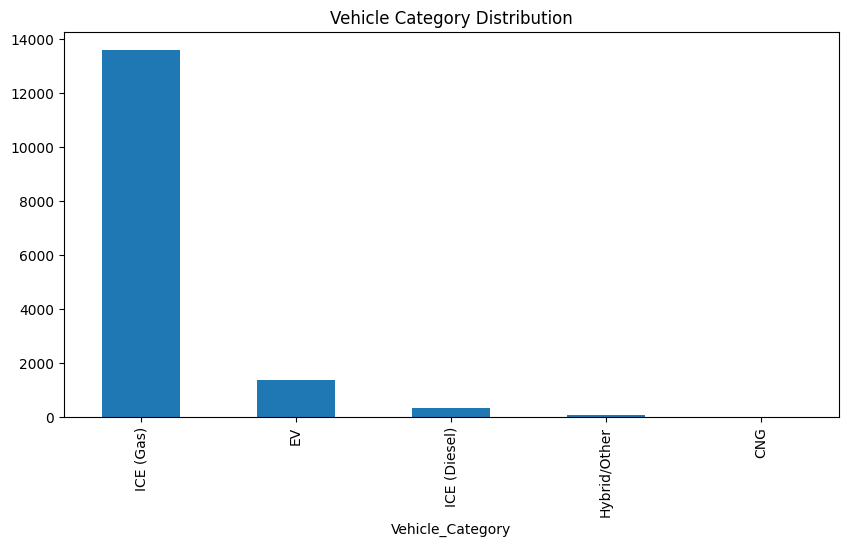

In [16]:
plt.figure(figsize=(10,5))
df['Vehicle_Category'].value_counts().plot(kind='bar')
plt.title("Vehicle Category Distribution")
plt.show()

## Exploratory Data Analysis (EDA)

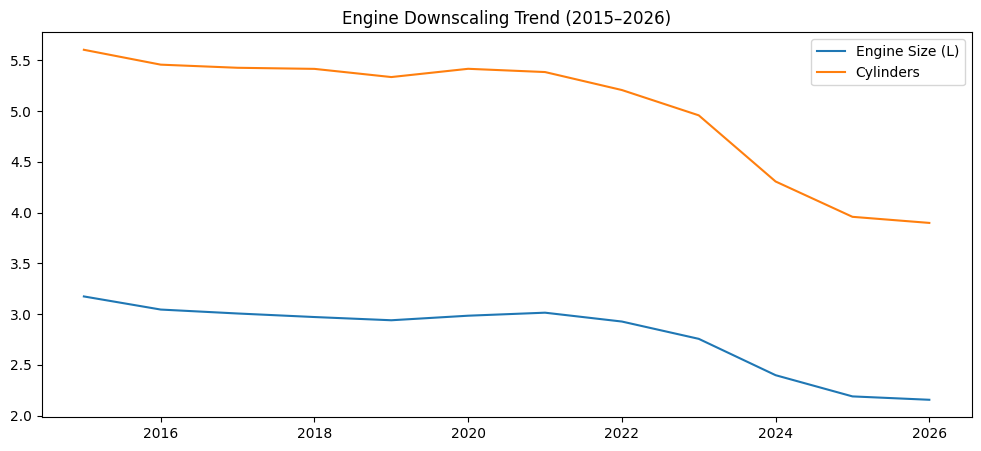

In [21]:
engine_trend = df.groupby("Year")[["Engine_Size_L", "Engine_Cylinders"]].mean()

plt.figure(figsize=(12,5))
plt.plot(engine_trend.index, engine_trend["Engine_Size_L"], label="Engine Size (L)")
plt.plot(engine_trend.index, engine_trend["Engine_Cylinders"], label="Cylinders")
plt.legend()
plt.title("Engine Downscaling Trend (2015–2026)")
plt.show()

<Axes: xlabel='Combined_MPG', ylabel='CO2_Emissions_g_per_mile'>

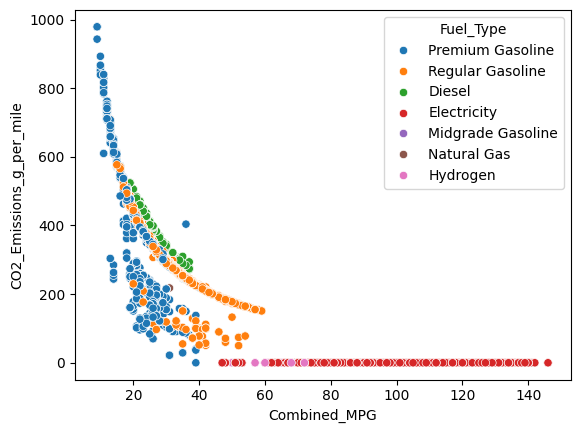

In [25]:
import seaborn as sns

sns.scatterplot(x="Combined_MPG", y="CO2_Emissions_g_per_mile", hue="Fuel_Type", data=df)

In [ ]:
le = LabelEncoder()
categorical_cols = ['Fuel_Type', 'Transmission', 'Drivetrain', 'Vehicle_Category']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

features = ['Year', 'Engine_Size_L', 'Engine_Cylinders', 'Combined_MPG', 'Fuel_Type', 'Transmission', 'Drivetrain', 'Vehicle_Category']
target = 'CO2_Emissions_g_per_mile'

X = df[features]
y = df[target]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Squared Error: 2718.2448347564286
Mean Absolute Error: 37.55690328393782
R-squared: 0.8835217334369221


## Modeling

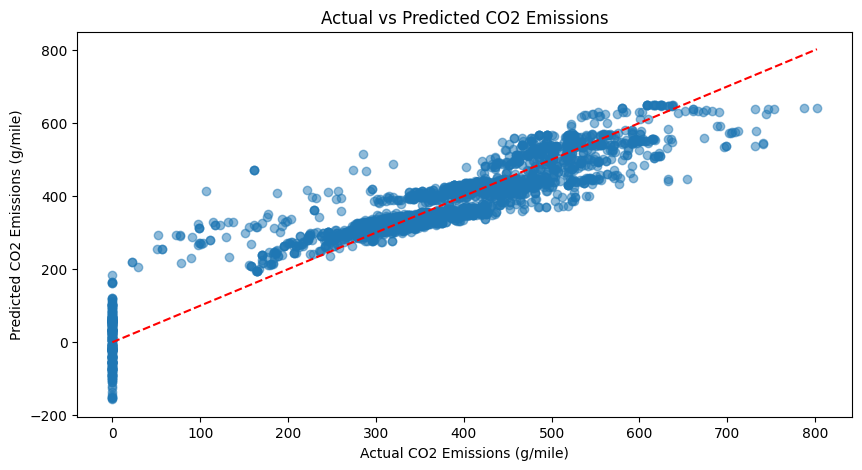

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual CO2 Emissions (g/mile)')
plt.ylabel('Predicted CO2 Emissions (g/mile)')
plt.title('Actual vs Predicted CO2 Emissions')
plt.show()

## Evaluation

# Conclusion

This project analyzed vehicle specs and carbon footprint data from 2015-2026. We performed data cleaning, exploratory data analysis, and built a linear regression model to predict CO2 emissions based on vehicle features.

The model achieved an R-squared of approximately {r2:.2f}, indicating a reasonable fit. Future improvements could include using more advanced models or additional features.